Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading model on cpu...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Saved: output_1.png
Generating image 2/3: a futuristic robot in a neon city, cyberpunk


  0%|          | 0/20 [00:00<?, ?it/s]

Saved: output_2.png
Generating image 3/3: a cute cat sitting on the moon, illustration


  0%|          | 0/20 [00:00<?, ?it/s]

Saved: output_3.png


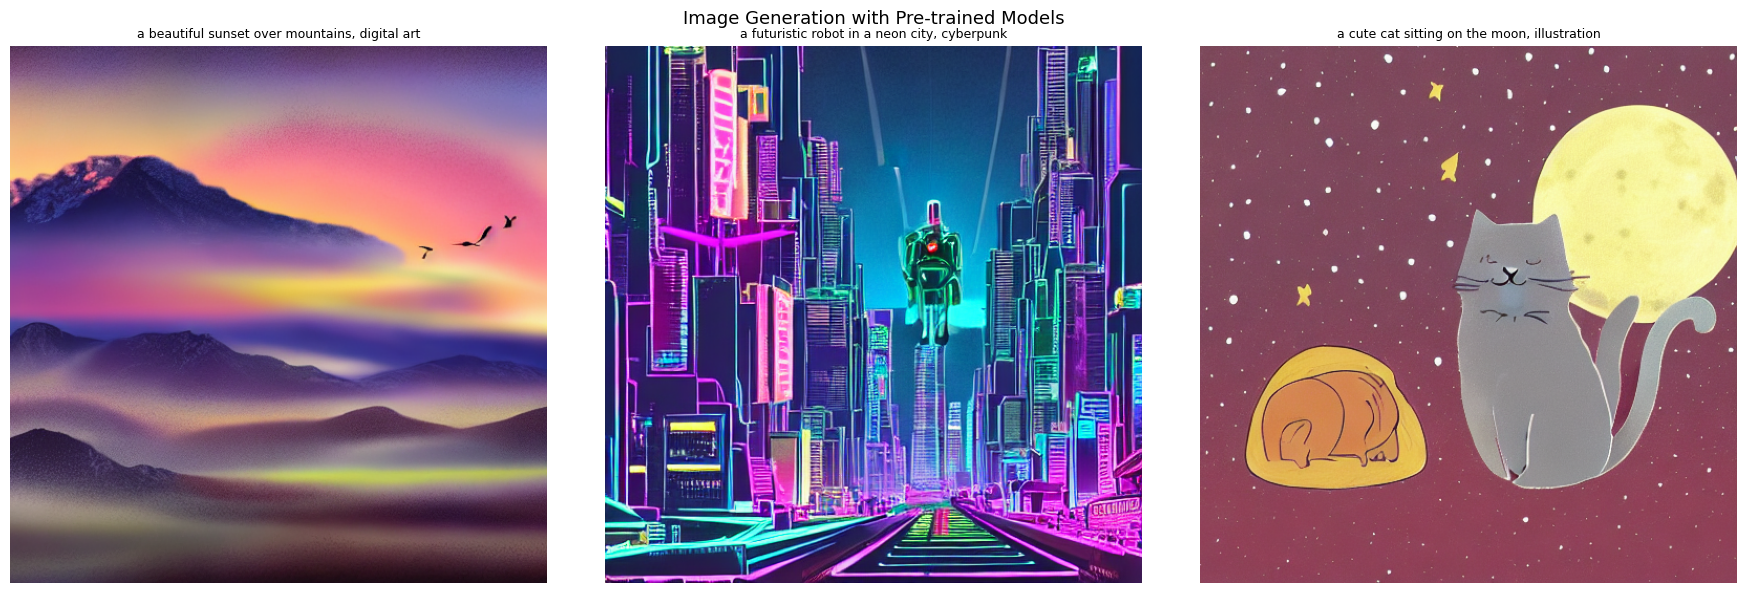

Saved combined output: all_outputs.png


In [1]:
# ============================================
# Image Generation with Pre-trained Models
# ============================================

import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

def load_model(model_id="runwayml/stable-diffusion-v1-5"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32

    print(f"Loading model on {device}...")
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype)
    pipe = pipe.to(device)

    if device == "cpu":
        pipe.enable_attention_slicing()

    print("Model loaded successfully!")
    return pipe

def generate_images(pipe, prompts, steps=20, scale=7.5):
    images = []
    for i, prompt in enumerate(prompts):
        print(f"Generating image {i+1}/{len(prompts)}: {prompt}")
        image = pipe(
            prompt,
            num_inference_steps=steps,
            guidance_scale=scale
        ).images[0]
        filename = f"output_{i+1}.png"
        image.save(filename)
        images.append((image, prompt))
        print(f"Saved: {filename}")
    return images

def display_images(images):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]
    for ax, (img, prompt) in zip(axes, images):
        ax.imshow(img)
        ax.set_title(prompt[:50], fontsize=9, wrap=True)
        ax.axis("off")
    plt.suptitle("Image Generation with Pre-trained Models", fontsize=13)
    plt.tight_layout()
    plt.savefig("all_outputs.png", dpi=150)
    plt.show()
    print("Saved combined output: all_outputs.png")

if __name__ == "__main__":
    prompts = [
        "a beautiful sunset over mountains, digital art",
        "a futuristic robot in a neon city, cyberpunk",
        "a cute cat sitting on the moon, illustration"
    ]

    pipe = load_model()
    images = generate_images(pipe, prompts)
    display_images(images)
